# 06 — Génération de la soumission
### Atlantic Haven Hotels — Prédiction d'annulation de réservation

Ce notebook correspond à l'**étape 6** du sujet : génération de `submission.csv` à partir de
`reservations_test.csv`, **sans modifier l'ordre des identifiants**.

Le fichier produit contient exactement trois colonnes :
- `reservation_id` — l'identifiant, dans l'ordre du fichier de test ;
- `probabilite_annulation` — la probabilité prédite, entre 0 et 1 ;
- `reservation_annulee` — la décision binaire issue du seuil retenu.

## 0. Configuration et chargement

In [1]:
import sys, os, json
for _candidate in (".", ".."):
    if os.path.isdir(os.path.join(_candidate, "src")):
        if _candidate not in sys.path:
            sys.path.insert(0, _candidate)
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier

from src.config import RANDOM_STATE, SUBMISSION_PATH, ARTIFACTS_DIR, ID_COL
from src.data import load_train_test, temporal_split
from src.preprocessing import prepare_features, make_pipeline
from src.evaluation import evaluate, threshold_curve
from src.model_io import load_model, save_model

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")

train, test, data_dict = load_train_test()
print("Train :", train.shape, "| Test :", test.shape)

Train : (8000, 34) | Test : (2000, 33)


## 6.1 Détermination du seuil de décision

Le seuil est déterminé sur le **jeu de validation temporelle** (les 20% de réservations les plus
récentes du train), c'est-à-dire sur des données que le modèle n'a pas vues à l'entraînement et qui
sont chronologiquement les plus proches du jeu de test. C'est l'estimation la plus honnête du seuil
optimal pour des données futures.

In [2]:
X_tr, X_val, y_tr, y_val, split_date = temporal_split(train)
X_tr_p, X_val_p = prepare_features(X_tr), prepare_features(X_val)

model_val = load_model("xgboost_v1")
val_proba = model_val.predict_proba(X_val_p)[:, 1]

thresholds, f1s, precisions, recalls = threshold_curve(y_val, val_proba)
SEUIL = float(thresholds[np.argmax(f1s)])
val_results, _ = evaluate(y_val, val_proba, threshold=SEUIL, label="XGBoost — validation")

print(f"Seuil retenu (maximise le F1 sur la validation) : {SEUIL:.3f}")
print(f"F1 = {val_results['f1']:.4f} | Précision = {val_results['precision']:.4f} "
      f"| Rappel = {val_results['recall']:.4f} | AUC = {val_results['roc_auc']:.4f}")

Seuil retenu (maximise le F1 sur la validation) : 0.425
F1 = 0.4842 | Précision = 0.3468 | Rappel = 0.8019 | AUC = 0.6565


## 6.2 Réentraînement sur l'intégralité du jeu d'entraînement

Le modèle utilisé pour la validation n'a été entraîné que sur 80% du train (les 6400 réservations les
plus anciennes). Pour la soumission, on le réentraîne sur les **8000 lignes**, avec exactement les mêmes
hyperparamètres.

**Pourquoi c'est justifié ici :** les 1600 lignes supplémentaires sont les plus **récentes**, donc les
plus proches temporellement du jeu de test — les exclure reviendrait à priver le modèle de l'information
la plus pertinente. Le seuil, lui, reste celui estimé sur la validation : le réajuster sur des données
d'entraînement donnerait une valeur optimiste et non représentative.

In [3]:
with open(ARTIFACTS_DIR / "xgboost_v1.json") as f:
    xgb_meta = json.load(f)
xgb_best_params = {k.replace("model__", ""): v for k, v in xgb_meta["best_params"].items()}
print("Hyperparamètres (issus du réglage de l'étape 3) :", xgb_best_params)

# Jeu d'entraînement complet, trié par date pour cohérence (l'ordre n'affecte pas XGBoost)
train_full = train.sort_values("date_reservation").reset_index(drop=True)
X_full = prepare_features(train_full.drop(columns=["reservation_annulee"]))
y_full = train_full["reservation_annulee"]

scale_pos_weight_full = (y_full == 0).sum() / (y_full == 1).sum()

final_model = make_pipeline(XGBClassifier(
    scale_pos_weight=scale_pos_weight_full, random_state=RANDOM_STATE,
    eval_metric="logloss", n_jobs=-1, **xgb_best_params,
))
final_model.fit(X_full, y_full)

print(f"\nModèle final réentraîné sur {len(X_full)} lignes "
      f"({train_full['date_reservation'].min().date()} → {train_full['date_reservation'].max().date()})")

Hyperparamètres (issus du réglage de l'étape 3) : {'subsample': 0.85, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.85}



Modèle final réentraîné sur 8000 lignes (2023-01-01 → 2025-05-24)


## 6.3 Prédiction sur le jeu de test

**Point critique :** on applique `prepare_features` au test sans jamais réordonner les lignes. Les
identifiants sont extraits du DataFrame de test original, garantissant que l'ordre du fichier de
soumission correspond exactement à celui de `reservations_test.csv`.

In [4]:
X_test_p = prepare_features(test)

# Vérification : mêmes colonnes que l'entraînement, dans le même ordre
assert list(X_test_p.columns) == list(X_full.columns), "Décalage de colonnes entre train et test"
print("Colonnes train/test alignées :", X_test_p.shape[1], "variables")

# Vérification : catégories inconnues gérées par le pipeline (handle_unknown="ignore")
for c in ["type_destination", "segment_client", "marche_origine", "canal_reservation",
          "moyen_transport", "formule_repas", "tarif_remboursable", "type_acompte",
          "client_type", "agent_id"]:
    nouvelles = set(X_test_p[c].dropna().unique()) - set(X_full[c].dropna().unique())
    if nouvelles:
        print(f"  Catégories inédites dans {c} : {nouvelles} (gérées par handle_unknown='ignore')")

test_proba = final_model.predict_proba(X_test_p)[:, 1]
test_pred = (test_proba >= SEUIL).astype(int)

print(f"\nPrédictions générées pour {len(test_proba)} réservations")
print(f"Taux d'annulation prédit : {test_pred.mean():.3f} (taux observé sur le train : {y_full.mean():.3f})")

Colonnes train/test alignées : 27 variables
  Catégories inédites dans canal_reservation : {'assistant_vocal'} (gérées par handle_unknown='ignore')

Prédictions générées pour 2000 réservations
Taux d'annulation prédit : 0.642 (taux observé sur le train : 0.258)


## 6.4 Contrôles de cohérence avant écriture

Avant d'écrire le fichier, on vérifie que les prédictions sur le test sont plausibles au regard de ce
qu'on a observé en validation — un écart important signalerait un problème de pipeline ou une dérive
temporelle marquée.

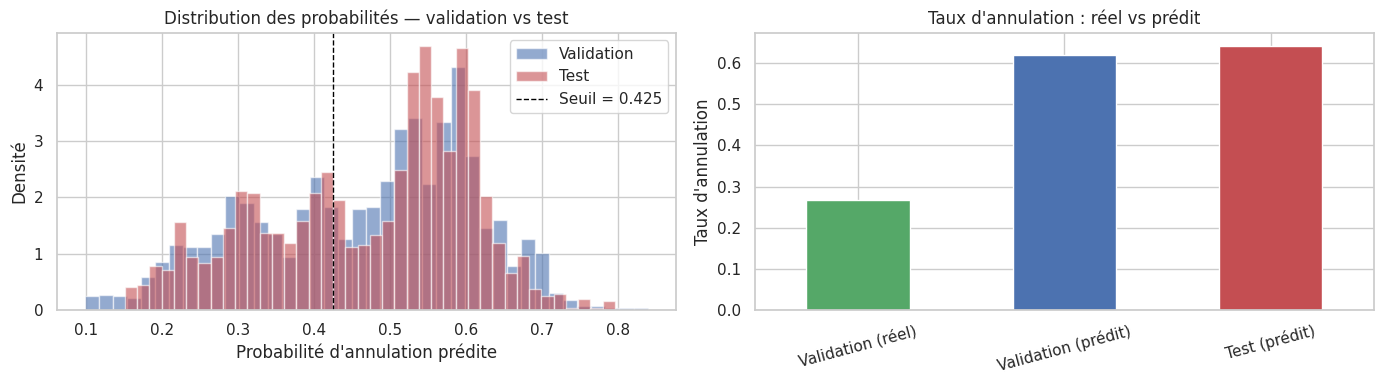

Validation (réel)      0.2681
Validation (prédit)    0.6200
Test (prédit)          0.6420
dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(val_proba, bins=40, alpha=0.6, label="Validation", color="#4C72B0", density=True)
axes[0].hist(test_proba, bins=40, alpha=0.6, label="Test", color="#C44E52", density=True)
axes[0].axvline(SEUIL, color="black", linestyle="--", linewidth=1, label=f"Seuil = {SEUIL:.3f}")
axes[0].set_xlabel("Probabilité d'annulation prédite")
axes[0].set_ylabel("Densité")
axes[0].set_title("Distribution des probabilités — validation vs test")
axes[0].legend()

comparaison = pd.Series({
    "Validation (réel)": y_val.mean(),
    "Validation (prédit)": (val_proba >= SEUIL).mean(),
    "Test (prédit)": test_pred.mean(),
})
comparaison.plot(kind="bar", ax=axes[1], color=["#55A868", "#4C72B0", "#C44E52"])
axes[1].set_ylabel("Taux d'annulation")
axes[1].set_title("Taux d'annulation : réel vs prédit")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

print(comparaison.round(4))

**Point important à assumer explicitement :** le modèle prédit ~62-64% d'annulations, alors que le taux
réel est d'environ 26%. Ce n'est pas une anomalie de pipeline, mais la **conséquence directe de
l'optimisation du F1-score** demandée par le sujet, sur un problème où le signal disponible est modéré
(AUC ≈ 0.66).

Le tableau ci-dessous montre l'arbitrage : ramener le taux prédit à une valeur « réaliste » (~26%)
exigerait un seuil de ~0.575, au prix d'une chute du F1 de 0.484 à 0.408 — soit une perte de 16% sur la
métrique évaluée. Le F1 récompense ici le rappel, et le rappel s'obtient en ratissant large.

In [6]:
arbitrage = pd.DataFrame({
    "seuil": thresholds,
    "f1": f1s,
    "precision": precisions,
    "recall": recalls,
    "taux_predit": [(val_proba >= t).mean() for t in thresholds],
})
apercu = arbitrage[(arbitrage["seuil"] >= 0.40) & (arbitrage["seuil"] <= 0.62)].round(4)
print(f"Taux d'annulation réel en validation : {y_val.mean():.4f}\n")
print(apercu.to_string(index=False))

idx_realiste = (arbitrage["taux_predit"] - y_val.mean()).abs().idxmin()
print(f"\nSeuil 'réaliste' (taux prédit ≈ taux réel) : {arbitrage.loc[idx_realiste, 'seuil']:.3f} "
      f"→ F1 = {arbitrage.loc[idx_realiste, 'f1']:.4f}")
print(f"Seuil retenu (F1 maximal)                  : {SEUIL:.3f} → F1 = {f1s.max():.4f}")

Taux d'annulation réel en validation : 0.2681

 seuil     f1  precision  recall  taux_predit
 0.425 0.4842     0.3468  0.8019       0.6200
 0.450 0.4771     0.3467  0.7646       0.5913
 0.475 0.4750     0.3544  0.7203       0.5450
 0.500 0.4619     0.3561  0.6573       0.4950
 0.525 0.4424     0.3620  0.5688       0.4212
 0.550 0.4189     0.3743  0.4755       0.3406
 0.575 0.4077     0.3987  0.4172       0.2806
 0.600 0.3272     0.4197  0.2681       0.1713

Seuil 'réaliste' (taux prédit ≈ taux réel) : 0.575 → F1 = 0.4077
Seuil retenu (F1 maximal)                  : 0.425 → F1 = 0.4842


**Conséquence opérationnelle :** ce seuil est adapté à l'objectif de l'examen (maximiser le F1), mais
il ne serait **pas** le bon choix pour un déploiement réel tel quel. En production, le seuil devrait être
fixé selon le coût métier réel de chaque erreur, et non selon le F1 — c'est précisément pourquoi
l'analyse du notebook 05 recommande une **utilisation graduée des probabilités** (actions non punitives,
adaptées à la tranche de risque) plutôt qu'une décision binaire unique appliquée uniformément.

**Sur la catégorie inédite `assistant_vocal` :** le jeu de test contient un canal de réservation absent
du train, reflet d'une évolution des usages entre les deux périodes. Le pipeline la gère sans erreur
grâce à `handle_unknown="ignore"` dans le `OneHotEncoder` : ces réservations sont encodées comme
n'appartenant à aucun canal connu, et le modèle s'appuie sur leurs autres variables. C'est le comportement
souhaité — il évite un plantage en production — mais ces prédictions sont mécaniquement moins informées,
et un réentraînement périodique reste nécessaire pour intégrer les nouveaux canaux.

## 6.5 Génération de `submission.csv`

In [7]:
submission = pd.DataFrame({
    "reservation_id": test["reservation_id"],
    "probabilite_annulation": test_proba,
    "reservation_annulee": test_pred,
})

submission.to_csv(SUBMISSION_PATH, index=False)
print(f"Fichier écrit : {SUBMISSION_PATH}")
submission.head(10)

Fichier écrit : /home/claude/atlantic-haven/submission.csv


,reservation_id,probabilite_annulation,reservation_annulee
0,R002267,0.436827,1
1,R002852,0.310101,0
2,R003752,0.598184,1
3,R009926,0.559619,1
4,R000141,0.543575,1
5,R004537,0.534861,1
6,R004983,0.498870,1
7,R005365,0.515084,1
8,R006971,0.587214,1
9,R008403,0.677752,1


## 6.6 Vérifications finales du fichier de soumission

On relit le fichier depuis le disque (et non la variable en mémoire) pour valider ce qui a réellement été
écrit, en reprenant point par point la checklist du sujet.

In [8]:
check = pd.read_csv(SUBMISSION_PATH)

controles = {
    "Nombre de lignes = 2000": len(check) == 2000,
    "Colonnes exactes et dans l'ordre": list(check.columns) == ["reservation_id", "probabilite_annulation", "reservation_annulee"],
    "Ordre des identifiants préservé": (check["reservation_id"].values == test["reservation_id"].values).all(),
    "Identifiants uniques": check["reservation_id"].is_unique,
    "Probabilités dans [0, 1]": check["probabilite_annulation"].between(0, 1).all(),
    "Décisions binaires (0 ou 1)": set(check["reservation_annulee"].unique()).issubset({0, 1}),
    "Aucune valeur manquante": not check.isnull().any().any(),
    "Cohérence probabilité/décision": ((check["probabilite_annulation"] >= SEUIL).astype(int) == check["reservation_annulee"]).all(),
}

for libelle, ok in controles.items():
    print(f"  {'OK  ' if ok else 'ÉCHEC'} — {libelle}")

assert all(controles.values()), "Au moins un contrôle a échoué — ne pas soumettre en l'état"
print("\nTous les contrôles sont passés : le fichier est conforme aux exigences du sujet.")

  OK   — Nombre de lignes = 2000
  OK   — Colonnes exactes et dans l'ordre
  OK   — Ordre des identifiants préservé
  OK   — Identifiants uniques
  OK   — Probabilités dans [0, 1]
  OK   — Décisions binaires (0 ou 1)
  OK   — Aucune valeur manquante
  OK   — Cohérence probabilité/décision

Tous les contrôles sont passés : le fichier est conforme aux exigences du sujet.


In [9]:
print("=== Résumé de la soumission ===")
print(f"Modèle              : XGBoost (réglé par validation croisée temporelle)")
print(f"Hyperparamètres     : {xgb_best_params}")
print(f"Entraîné sur        : {len(X_full)} réservations")
print(f"Seuil de décision   : {SEUIL:.3f} (optimisé sur validation temporelle)")
print(f"F1 attendu          : ~{val_results['f1']:.4f} (estimé sur validation)")
print()
print(f"Réservations prédites comme annulées : {test_pred.sum()} / {len(test_pred)} ({test_pred.mean()*100:.1f}%)")
print(f"Probabilité moyenne : {test_proba.mean():.4f} | médiane : {np.median(test_proba):.4f}")

save_model(final_model, "xgboost_final_full_train", metadata={
    "seuil": SEUIL, "best_params": xgb_best_params,
    "n_train": int(len(X_full)), "f1_validation": val_results["f1"],
})

=== Résumé de la soumission ===
Modèle              : XGBoost (réglé par validation croisée temporelle)
Hyperparamètres     : {'subsample': 0.85, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.85}
Entraîné sur        : 8000 réservations
Seuil de décision   : 0.425 (optimisé sur validation temporelle)
F1 attendu          : ~0.4842 (estimé sur validation)

Réservations prédites comme annulées : 1284 / 2000 (64.2%)
Probabilité moyenne : 0.4738 | médiane : 0.5156
Modèle sauvegardé : /home/claude/atlantic-haven/artifacts/xgboost_final_full_train.joblib


PosixPath('/home/claude/atlantic-haven/artifacts/xgboost_final_full_train.joblib')